In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
from IPython.core.display import display, HTML
from matplotlib import pyplot as plt
from matplotlib import ticker as mpl_ticker
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import seaborn as sns
from slugify import slugify
from teeplot import teeplot as tp
from tqdm import tqdm


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmp9m8c
interpreter: 3.10.12 (main, Jun 22 2026, 18:55:27) [GCC 11.4.0]
notebook name: 2026-08-15-nobg-pgcomplex-screen
notebook path: /home/runner/work/oee4/oee4/binder/2026-08-15-nobg-pgcomplex-screen.ipynb
revision: bdac574
timestamp: 2026-08-17T20:37:11Z00:00

IPython==7.16.1
packaging==26.2


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2026-08-15-nobg-pgcomplex-screen"


In [5]:
df_all = []
for endeavor in [17, *range(20, 29)]:
    for what, prefix in [
        ("nobb", f"endeavor={endeavor}/external-competitions/stage=2+what=collated/"),
        ("selfbb", f"endeavor={endeavor}/external-competitions-focalbb/stage=2+what=collated/"),
        ("truebb", f"endeavor={endeavor}/external-competitions-focalbb-true/stage=2+what=collated/"),
    ]:
        s3_handle = boto3.resource(
            's3',
            region_name="us-east-2",
            config=botocore.config.Config(
                signature_version=botocore.UNSIGNED,
            ),
        )
        bucket_handle = s3_handle.Bucket("prq49-20stint")


        competitions = bucket_handle.objects.filter(Prefix=prefix)
        dfs = [
            pd.read_csv(
            f's3://prq49-20stint/{competitions.key}',
            )
            for competitions in competitions
        ]
        print(len(dfs))
        df = pd.concat(dfs, ignore_index=True)
        df["kind"] = what

        df_all.append(df)

df_ecoselfcontext = pd.concat(df_all, ignore_index=True)


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


teeplots/2026-08-15-nobg-pgcomplex-screen/viz=scatterplot+x=truebb+y=selfbb+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/viz=scatterplot+x=truebb+y=selfbb+ext=.png


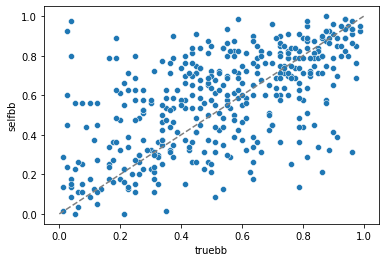

In [6]:
dfx = df_ecoselfcontext.loc[
    (df_ecoselfcontext["Root ID"] == 0),
    ["Competition Series","Focal Prevalence", "kind"],
]
with tp.teed(
    sns.scatterplot,
    data=dfx.round().groupby(["Competition Series", "kind"]).mean().reset_index().pivot(
        index="Competition Series", columns="kind", values="Focal Prevalence"
    ),
    x="truebb",
    y="selfbb",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.plot([0, 1], [0, 1], ls="--", c="gray")  # Add a diagonal reference line


teeplots/2026-08-15-nobg-pgcomplex-screen/hue=kind+viz=boxplot+y=focal-prevalence+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/hue=kind+viz=boxplot+y=focal-prevalence+ext=.png


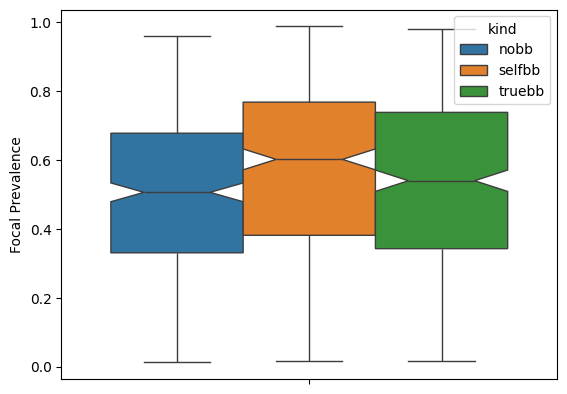

In [7]:
with tp.teed(
    sns.boxplot,
    data=dfx.groupby(["Competition Series", "kind"]).mean().reset_index().astype(
        {"Competition Series": str},
    ),
    y="Focal Prevalence",
    hue="kind",
    notch=True,
    teeplot_subdir=teeplot_subdir,
) as ax:
    pass


# get data


In [8]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49-20stint')

dfs = []
for endeavor in [17, *range(20, 29)]:
    series_profiles, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/series-profiles/stage=8+what=elaborated/',
    )
    df = pd.read_csv(
        f's3://prq49-20stint/{series_profiles.key}',
        compression='xz',
    )
    dfs.append(df)

df_pgcomplex = pd.concat(dfs, ignore_index=True)


# how does fitness complexity change over time?


In [9]:
x = "Flagged Advantageous Sites"
y = "Cardinal Interface Complexity"

data = df_pgcomplex[[x, y, "Series"]].reset_index().dropna()
data["x_quantile"] = data[x].rank(pct=True)
data["y_quantile"] = data[y].rank(pct=True)
data["score"] = data[["x_quantile", "y_quantile"]].min(axis=1)
dft = data.nlargest(
    20,
    "score",
    keep="all"
)
data["target"] = data.index.isin(dft.index)
dft


,index,Flagged Advantageous Sites,Cardinal Interface Complexity,Series,x_quantile,y_quantile,score
103,103,47.0,14.0,21023,0.997475,0.994949,0.994949
28,28,40.0,13.0,17028,0.994949,0.988636,0.988636
105,105,33.0,13.0,21025,0.984848,0.988636,0.984848
152,152,31.0,10.0,22032,0.973485,0.968434,0.968434
380,380,49.0,10.0,28020,1.000000,0.968434,0.968434
356,356,29.0,10.0,27036,0.958333,0.968434,0.958333
77,77,30.0,9.0,20037,0.964646,0.952020,0.952020
133,133,39.0,9.0,22013,0.992424,0.952020,0.952020
134,134,31.0,8.0,22014,0.973485,0.930556,0.930556
338,338,30.0,8.0,27018,0.964646,0.930556,0.930556


$r=0.09,\rho=0.10$
$p=0.060,0.052$
teeplots/2026-08-15-nobg-pgcomplex-screen/viz=regplot+x=fitness-no-bkgd+y=phenotype-complexity+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/viz=regplot+x=fitness-no-bkgd+y=phenotype-complexity+ext=.png


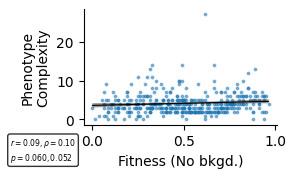

teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+split=phenotype-complexity-split-x+viz=boxplot+x=split+y=fitness-no-bkgd+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+split=phenotype-complexity-split-x+viz=boxplot+x=split+y=fitness-no-bkgd+ext=.png


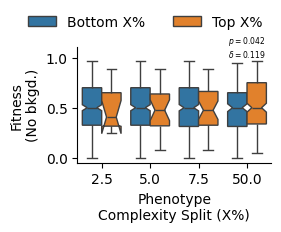

teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+viz=boxplot+x=split+y=phenotype-complexity+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+viz=boxplot+x=split+y=phenotype-complexity+ext=.png


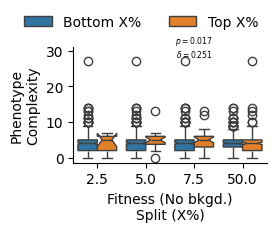

$r=0.04,\rho=0.02$
$p=0.378,0.729$
teeplots/2026-08-15-nobg-pgcomplex-screen/viz=regplot+x=fitness-no-bkgd+y=genotype-complexity+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/viz=regplot+x=fitness-no-bkgd+y=genotype-complexity+ext=.png


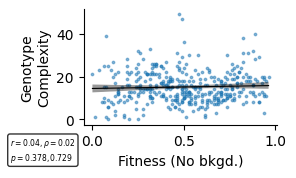

teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+split=genotype-complexity-split-x+viz=boxplot+x=split+y=fitness-no-bkgd+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+split=genotype-complexity-split-x+viz=boxplot+x=split+y=fitness-no-bkgd+ext=.png


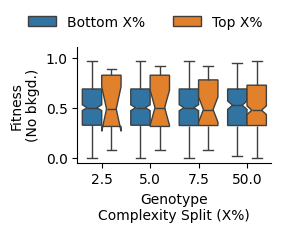

teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+viz=boxplot+x=split+y=genotype-complexity+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+viz=boxplot+x=split+y=genotype-complexity+ext=.png


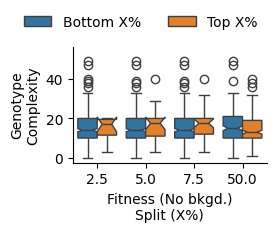

$r=0.06,\rho=0.07$
$p=0.246,0.157$
teeplots/2026-08-15-nobg-pgcomplex-screen/viz=regplot+x=fitness-no-bkgd+y=p-g-joint-exceedance+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/viz=regplot+x=fitness-no-bkgd+y=p-g-joint-exceedance+ext=.png


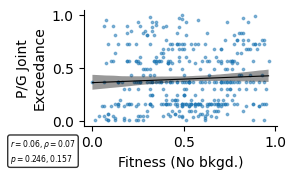

teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+split=p-g-joint-exceedance-split-x+viz=boxplot+x=split+y=fitness-no-bkgd+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+split=p-g-joint-exceedance-split-x+viz=boxplot+x=split+y=fitness-no-bkgd+ext=.png


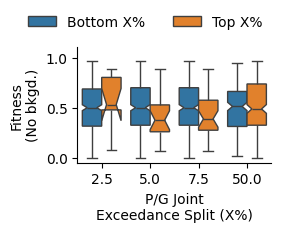

teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+viz=boxplot+x=split+y=p-g-joint-exceedance+ext=.pdf
teeplots/2026-08-15-nobg-pgcomplex-screen/hue=top+viz=boxplot+x=split+y=p-g-joint-exceedance+ext=.png


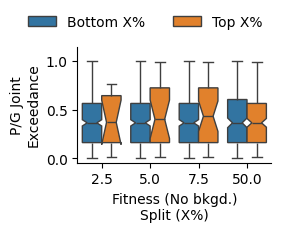

In [10]:
data = df_pgcomplex[["Flagged Advantageous Sites", "Cardinal Interface Complexity", "Series"]].reset_index().dropna()
data["x_quantile"] = data["Flagged Advantageous Sites"].rank(pct=True)
data["y_quantile"] = data["Cardinal Interface Complexity"].rank(pct=True)
data["score"] = data[["x_quantile", "y_quantile"]].min(axis=1)

data["Phenotype\nComplexity"] = data["Cardinal Interface Complexity"]
data["Genotype\nComplexity"] = data["Flagged Advantageous Sites"]
data["P/G Joint\nExceedance"] = data["score"]

dfx = df_ecoselfcontext.loc[
    (df_ecoselfcontext["Root ID"] == 0),
    ["Competition Series","Focal Prevalence", "kind"],
]
dfx["Focal Prevalence"] = dfx["Focal Prevalence"].round()
dfx["target"] = dfx["Competition Series"].isin(dft["Series"])
dfp = dfx.groupby(
    ["Competition Series", "kind", "target"],
).mean().reset_index().pivot(
    columns="kind",
    index=["Competition Series", "target"],
    values="Focal Prevalence",
).reset_index()
dfp["Fitness (No bkgd.)"] = dfp["nobb"]

data = pd.merge(
    data,
    dfp,
    how="left",
    left_on="Series",
    right_on="Competition Series",
)

for y in ["Phenotype\nComplexity", "Genotype\nComplexity", "P/G Joint\nExceedance"]:
    # Calculate statistics
    pearson_r, pearson_p = scipy_stats.pearsonr(data["Fitness (No bkgd.)"], data[y])
    spearman_rho, spearman_p = scipy_stats.spearmanr(data["Fitness (No bkgd.)"], data[y])

    # Format the annotation string
    stats_text = (
        fr"$r={pearson_r:.2f},\rho={spearman_rho:.2f}$"
        + f"\n$p={pearson_p:.3f},{spearman_p:.3f}$"
    )
    print(stats_text)
    with tp.teed(
        sns.regplot,
        data=data,
        y=y,
        x="Fitness (No bkgd.)",
        line_kws={"color": "black", "lw": 0.8},

        teeplot_subdir=teeplot_subdir,
        scatter_kws={"alpha": 0.5, "clip_on": False, "s": 3},
    ) as ax:
        ax.collections[1].set_alpha(0.4)
        sns.despine(ax=ax)
        ax.figure.set_size_inches(2.5, 1.5)
        ax.text(-0.38, -0.1, stats_text,
                transform=ax.transAxes,
                fontsize=5.5,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    dfsx = []
    mwu_results = [] # Store p-values and delta for plotting

    for split in [0.025, 0.05, 0.075, 0.5]:
        split_df = data.copy()
        split_df["split"] = split * 100

        # Identify groups
        is_top = split_df[y] >= split_df[y].quantile(1 - split)

        group_top = split_df.loc[is_top, "Fitness (No bkgd.)"]
        group_bot = split_df.loc[~is_top, "Fitness (No bkgd.)"]

        stat, p_val = scipy_stats.mannwhitneyu(group_top, group_bot, alternative='two-sided')
        d, _ = cliffs_delta(group_top, group_bot) # Calculate Cliff's Delta

        mwu_results.append((p_val, d))

        # Assign string labels
        split_df["top"] = is_top.map({True: "Top X%", False: "Bottom X%"})
        dfsx.append(split_df)

    combined_split_df = pd.concat(dfsx, ignore_index=True)

    with tp.teed(
        sns.boxplot,
        data=combined_split_df,
        x="split",
        y="Fitness (No bkgd.)",
        hue="top",
        notch=True,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"split": slugify(f"{y} Split (X%)")},
    ) as ax:
        ax.figure.set_size_inches(2.5, 1.5)
        sns.despine(ax=ax)
        sns.move_legend(
            ax, "lower center",
            bbox_to_anchor=(.35, 1.05), ncol=3, title=None, frameon=False,
        )
        ax.set_xlabel(f"{y} Split (X%)")
        ax.set_ylabel("Fitness\n(No bkgd.)")

        # Determine y-limits to comfortably place annotations below the legend
        y_max = combined_split_df["Fitness (No bkgd.)"].max()
        y_min = combined_split_df["Fitness (No bkgd.)"].min()
        y_range = y_max - y_min
        ax.set_ylim(top=y_max + y_range * 0.15)

        # Annotate Mann-Whitney U test p-values and Cliff's Delta above each split group
        for i, (p_val, d) in enumerate(mwu_results):
            if p_val < 0.05:
                # Format for significance display
                if p_val < 0.001:
                    p_text = "$p < 0.001$"
                else:
                    p_text = f"$p = {p_val:.3f}$"

                # Add Cliff's Delta on a new line
                p_text += f"\n$\\delta={d:.3f}$"

                ax.text(
                    x=i,
                    y=y_max + (y_range * 0.02),
                    s=p_text,
                    ha='center',
                    va='bottom',
                    fontsize=5.5,
                    color='black'
                )

    dfsx = []
    mwu_results = [] # Store p-values and delta for plotting

    for split in [0.025, 0.05, 0.075, 0.5]:
        split_df = data.copy()
        split_df["split"] = split * 100

        # Identify groups
        is_top = split_df["Fitness (No bkgd.)"] >= split_df["Fitness (No bkgd.)"].quantile(1 - split)

        group_top = split_df.loc[is_top, y]
        group_bot = split_df.loc[~is_top, y]

        stat, p_val = scipy_stats.mannwhitneyu(group_top, group_bot, alternative='two-sided')
        d, _ = cliffs_delta(group_top, group_bot) # Calculate Cliff's Delta

        mwu_results.append((p_val, d))

        # Assign string labels
        split_df["top"] = is_top.map({True: "Top X%", False: "Bottom X%"})
        dfsx.append(split_df)

    combined_split_df = pd.concat(dfsx, ignore_index=True)

    with tp.teed(
        sns.boxplot,
        data=combined_split_df,
        x="split",
        y=y,
        hue="top",
        notch=True,
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        ax.figure.set_size_inches(2.5, 1.5)
        sns.despine(ax=ax)
        sns.move_legend(
            ax, "lower center",
            bbox_to_anchor=(.35, 1.05), ncol=3, title=None, frameon=False,
        )
        ax.set_xlabel("Fitness (No bkgd.)\nSplit (X%)")
        ax.set_ylabel(y)

        # Determine y-limits to comfortably place annotations below the legend
        y_max = combined_split_df[y].max()
        y_min = combined_split_df[y].min()
        y_range = y_max - y_min
        ax.set_ylim(top=y_max + y_range * 0.15)

        # Annotate Mann-Whitney U test p-values and Cliff's Delta above each split group
        for i, (p_val, d) in enumerate(mwu_results):
            if p_val < 0.05:
                # Format for significance display
                if p_val < 0.001:
                    p_text = "$p < 0.001$"
                else:
                    p_text = f"$p = {p_val:.3f}$"

                # Add Cliff's Delta on a new line
                p_text += f"\n$\\delta={d:.3f}$"

                ax.text(
                    x=i,
                    y=y_max + (y_range * 0.02),
                    s=p_text,
                    ha='center',
                    va='bottom',
                    fontsize=5.5,
                    color='black'
                )
